This is an exploration of the PyEphem and Skyfield API's that are used to filter `AllSkyImages` down to `NightSkyImages` for night-only images

In [1]:
import ephem
import pandas as pd
from datetime import datetime

Using PyEphem is so easy to just directly get a single value.

In [2]:
# Allegheny Observatory AllSky Camera location: 40.48250427897144, -80.02063960912749
observatory = ephem.Observer()
observatory.lat = "40.48250427897144"
observatory.lon = "-80.02063960912749"
observatory.elevation = 372.86
observatory

<ephem.Observer date='2026/4/16 20:13:58' epoch='2000/1/1 12:00:00' lon='-80:01:14.3' lat='40:28:57.0' elevation=372.86m horizon=0:00:00.0 temp=15.0C pressure=1010.0mBar>

In [3]:
moon = ephem.Moon()
moon.compute(observatory)
moon.alt, moon.az, moon.moon_phase

(0.5834540724754333, 4.40530252456665, 0.006559607079524077)

In [4]:
print(observatory.next_rising(moon))
print(observatory.next_setting(moon))

2026/4/17 10:22:47
2026/4/16 23:25:16


Let's try to learn Skyfield

In [5]:
from skyfield.api import load

ts = load.timescale(builtin=True)
planets = load("de405.bsp")
ts, planets

(<skyfield.timelib.Timescale at 0x7f09b776c6e0>, <SpiceKernel 'de405.bsp'>)

In [6]:
ts.utc(2010, range(1, 12))[0]

<Time tt=2455197.5007660184>

In [7]:
ts.now()
m = planets["moon"]
s = planets["sun"]
m, s

(<VectorSum of 2 vectors:
  'de405.bsp' segment 0 SOLAR SYSTEM BARYCENTER -> 3 EARTH BARYCENTER
  'de405.bsp' segment 3 EARTH BARYCENTER -> 301 MOON>,
 <ChebyshevPosition 'de405.bsp' segment 0 SOLAR SYSTEM BARYCENTER -> 10 SUN>)

In [8]:
from skyfield.api import N, W, wgs84
from skyfield.api import Time as SkyfieldTime
from skyfield.api import Angle
from skyfield.vectorlib import VectorSum

earth = planets["earth"]
allegheny: VectorSum = earth + wgs84.latlon(
    40.48250427897144 * N, 80.02063960912749 * W, 372.86
)


def get_altaz(target, ts: SkyfieldTime) -> tuple[Angle, Angle]:
    alt, az, _ = allegheny.at(ts).observe(target).apparent().altaz()
    return alt.degrees, az.degrees


get_altaz(s, ts.now())

(np.float64(41.21448990475638), np.float64(244.2967780810678))

In [9]:
# Want to populate a dataframe with a timestamp representing every minute in 2014
from pytz import timezone

eastern = timezone("US/Eastern")
start = eastern.localize(datetime(2010, 1, 1, 0, 0, 0))
end = eastern.localize(datetime(2010, 1, 31, 23, 59, 00))

duration = end - start

start, end, duration

(datetime.datetime(2010, 1, 1, 0, 0, tzinfo=<DstTzInfo 'US/Eastern' EST-1 day, 19:00:00 STD>),
 datetime.datetime(2010, 1, 31, 23, 59, tzinfo=<DstTzInfo 'US/Eastern' EST-1 day, 19:00:00 STD>),
 datetime.timedelta(days=30, seconds=86340))

In [10]:
ts = load.timescale()
t = ts.linspace(
    ts.from_datetime(start),
    ts.from_datetime(end),
    int((end - start).total_seconds() / 60),
)
apparent = allegheny.at(t).observe(s).apparent()
sun_alt, sun_az, _ = apparent.altaz()

sun_df = pd.DataFrame(
    {
        "timestamp": pd.date_range(start, end, freq="1min")[:-1],
        "alt": sun_alt.degrees,
        "az": sun_az.degrees,
    }
)
sun_df

,timestamp,alt,az
0,2010-01-01 00:00:00-05:00,-71.841222,342.418719
1,2010-01-01 00:01:00-05:00,-71.897450,343.135503
2,2010-01-01 00:02:00-05:00,-71.951396,343.856212
3,2010-01-01 00:03:00-05:00,-72.003039,344.580718
4,2010-01-01 00:04:00-05:00,-72.052358,345.308885
...,...,...,...
44634,2010-01-31 23:54:00-05:00,-65.207410,337.543768
44635,2010-01-31 23:55:00-05:00,-65.279012,338.087975
44636,2010-01-31 23:56:00-05:00,-65.348935,338.634893
44637,2010-01-31 23:57:00-05:00,-65.417163,339.184478


In [11]:
pd.date_range(start, end, freq="1min")
pd.DataFrame(pd.date_range(start, end, freq="1min", tz="US/Eastern")).map(
    lambda x: get_altaz(s, ts.from_datetime(x))
)

,0
0,"(-71.84122161319202, 342.41871910703196)"
1,"(-71.89744843337907, 343.13548665879824)"
2,"(-71.95139322325274, 343.8561797717004)"
3,"(-72.0030351638172, 344.5806690446225)"
4,"(-72.052354091071, 345.308819620981)"
...,...
44635,"(-65.20741636224187, 337.5438171433957)"
44636,"(-65.2790171536288, 338.08801225512127)"
44637,"(-65.3489379741752, 338.63491730462704)"
44638,"(-65.4171641497058, 339.184490457606)"


In [12]:
# there has GOT to be a better way. This is extraordinarily slow. I think a lot of the slowdown is the inefficiency for applying from datetimes when I don't even want them
ts.from_datetimes(pd.date_range(start, end, freq="1min", tz="US/Eastern").to_list())

<Time tt=[2455197.709099352 ... 2455228.7084049075] len=44640>

In [13]:
pd.DataFrame(
    [
        get_altaz(s, x)
        for x in ts.from_datetimes(
            pd.date_range(start, end, freq="1min", tz="US/Eastern").to_list()
        )
    ],
    columns=["alt", "az"],
)

,alt,az
0,-71.841222,342.418719
1,-71.897448,343.135487
2,-71.951393,343.856180
3,-72.003035,344.580669
4,-72.052354,345.308820
...,...,...
44635,-65.207416,337.543817
44636,-65.279017,338.088012
44637,-65.348938,338.634917
44638,-65.417164,339.184490


In [14]:
# it occurs to me I should test with a smaller time range. Duh. Stupid jet lag.
tup = get_altaz(s, ts.from_datetime(start))

there is something going on here with the unpacking. I will need to learn how to unpack the tuples correctly. It's trying to continue to unpack the angles themselves and I don't want that

Having trouble getting used to the Skyfield API

okay, so I'm not supposed to create a bunch of timeframes and do multiple observations, I'm supposed to do it once and i guess 'yield' all the points?

In the rhodesmill.org/skyfield/example-plots.html#charting-an-apparition-of-venus example, it seems there is a subsetting and domain cutting process
like

```python
ts = load.timescale()
start, end = ts.utc(2021, 3, 7), ts.utc(2022, 2, 7)

f = almanac.sunrise_sunset(eph, observer)
t, y = almanac.find_discrete(start, end, f)
sunsets = (y == 0)
t = t[sunsets]
```


<Axes: xlabel='timestamp'>

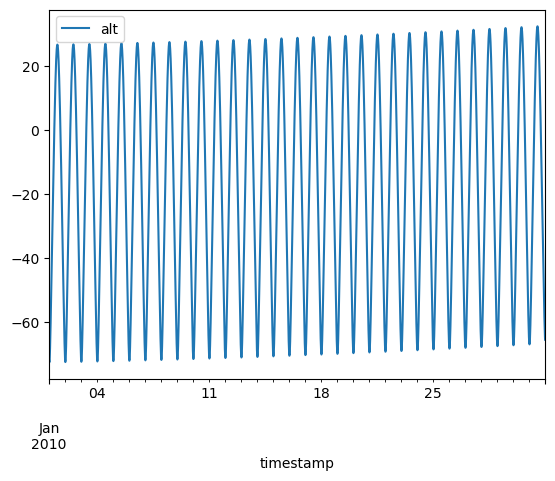

In [15]:
sun_df.plot.line(x="timestamp", y="alt")

Can also use linspace

In [16]:
eph = load("de405.bsp")
earth, sun, venus = eph["earth"], eph["sun"], eph["venus"]
observer = wgs84.latlon(+40.0, 0.0)

ts = load.timescale()
start, end = ts.utc(2021, 3, 7), ts.utc(2022, 2, 7)
ts.linspace(start, end, 50)

<Time tt=[2459280.500800741 ... 2459617.500800741] len=50>